## Loading data

In [47]:
import pandas as pd
import numpy as np
from pathlib import Path

BASE_DIR = Path().resolve().parent

rfm = pd.read_csv(BASE_DIR / "data/processed/rfm_segments.csv")

rfm.head()

,customer_unique_id,frequency,monetary,recency,R_score,F_score,M_score,RFM_score,segment
0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,161,4,1,3,413,Recent
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,164,4,1,1,411,Recent
2,0000f46a3911fa3c0805444483337064,1,86.22,586,1,1,2,112,Lost
3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,370,2,1,1,211,Lost
4,0004aac84e0df4da2b147fca70cf8255,1,196.89,337,2,1,4,214,Lost


In [48]:
features = rfm[["recency", "frequency", "monetary"]]

# Initial K-Means Clustering

In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

## Determining Optimal Number of Clusters

- The Elbow Method is used to evaluate clustering performance across different values of K.
- Inertia measures the compactness of clusters by calculating how far data points are from their assigned cluster centers. Lower inertia indicates tighter and more cohesive clusters.
- The optimal K is selected by identifying the point where inertia reduction begins to slow down significantly.

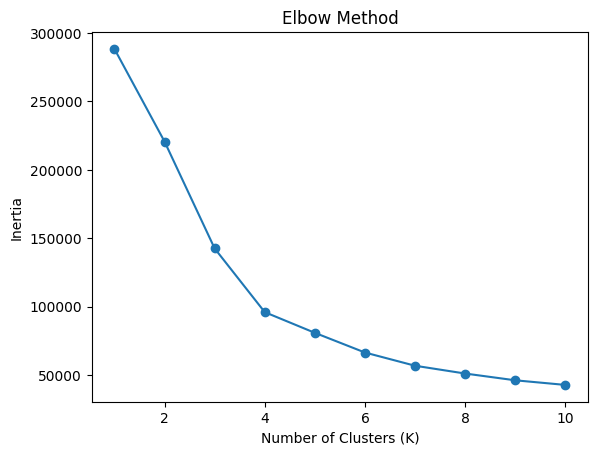

In [18]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [19]:
kmeans = KMeans(n_clusters=4, random_state=42)

rfm["cluster"] = kmeans.fit_predict(scaled_features)

In [20]:
rfm.groupby("cluster")[["recency", "frequency", "monetary"]].mean()

,recency,frequency,monetary
cluster,,,
0,178.926315,1.000000,134.994652
1,439.542927,1.000000,134.644484
2,290.122914,1.015466,1189.062764
3,269.306212,2.116475,290.305945


### Key Observations

- Cluster 0 represents active but low-spending customers.
- Cluster 1 contains inactive low-value customers with high recency and low spending.
- Cluster 2 contains customers with higher spending behavior.
- Cluster 3 shows stronger repeat purchase behavior compared to other segments.

## Cluster Visualization

<Axes: xlabel='recency', ylabel='monetary'>

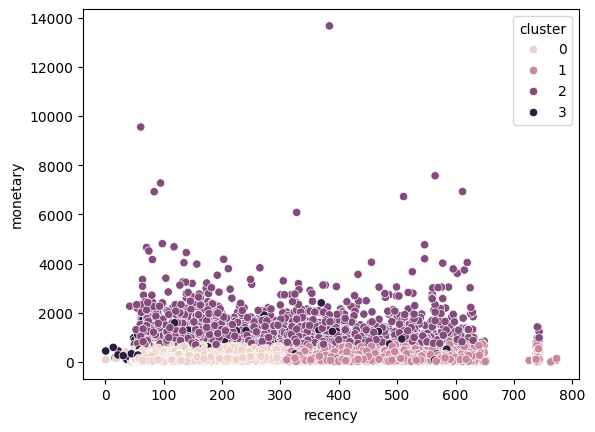

In [21]:
import seaborn as sns

sns.scatterplot(
    data=rfm,
    x="recency",
    y="monetary",
    hue="cluster"
)

<Axes: xlabel='frequency', ylabel='monetary'>

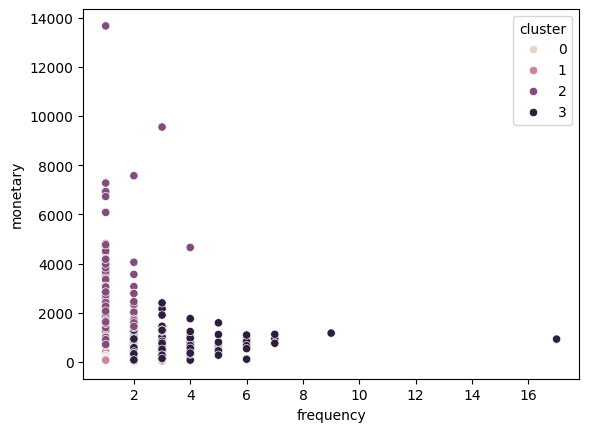

In [45]:
import seaborn as sns

sns.scatterplot(
    data=rfm,
    x="frequency",
    y="monetary",
    hue="cluster"
)

### Initial Clustering Observations

- Customer frequency showed very limited variation, with most customers making only a single purchase.
- Monetary values were highly skewed due to a small number of high-spending customers.
- One cluster became dominated by customers with extremely high monetary values, reducing the influence of recency and frequency during clustering.
- Significant overlap between clusters was observed in the scatter plot, indicating that the raw feature distributions were affecting cluster separation quality.

These observations suggested that additional preprocessing was required before applying K-Means more effectively. To reduce the impact of skewed distributions and extreme values, log transformation was applied to frequency and monetary features in the next step.

# Improving Customer Clustering with Log Transformation

- Initial clustering results showed significant overlap between customer groups due to highly skewed monetary values and outliers.
- Since K-Means relies on distance-based calculations, extreme spending values can dominate cluster formation and reduce the impact of other behavioral features such as frequency and recency.
- To improve cluster quality while preserving customer behavior patterns, log transformation is applied to frequency and monetary features before scaling and clustering.

In [22]:
rfm_log = rfm.copy()

rfm_log["frequency_log"] = np.log1p(rfm_log["frequency"])
rfm_log["monetary_log"] = np.log1p(rfm_log["monetary"])

In [23]:
features = rfm_log[
    ["recency", "frequency_log", "monetary_log"]
]

## Feature Scaling

- Since K-Means relies on distance calculations, features are standardized so that recency, frequency, and monetary contribute equally during clustering.

In [24]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

## Determining Optimal Number of Clusters

- The Elbow Method is used to evaluate clustering performance across different values of K.
- Inertia measures the compactness of clusters by calculating how far data points are from their assigned cluster centers. Lower inertia indicates tighter and more cohesive clusters.
- The optimal K is selected by identifying the point where inertia reduction begins to slow down significantly.

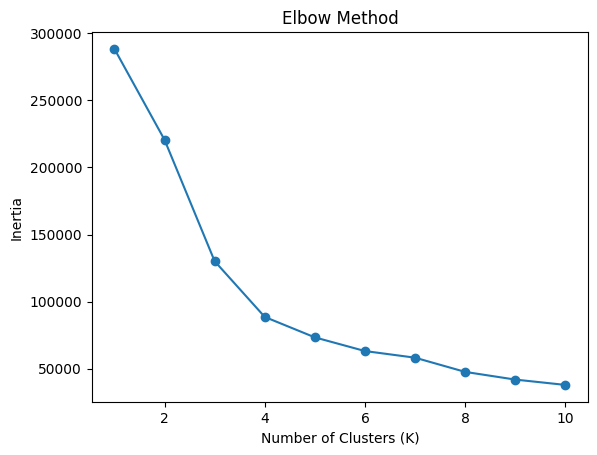

In [30]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, marker='o')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [31]:
kmeans = KMeans(n_clusters=4, random_state=42)

rfm_log["cluster"] = kmeans.fit_predict(scaled_features)

In [32]:
rfm_log.groupby("cluster")[
    ["recency", "frequency", "monetary"]
].mean()

,recency,frequency,monetary
cluster,,,
0,224.486109,1.000000,321.070696
1,477.162452,1.000000,120.076935
2,269.206874,2.116116,314.989226
3,197.943413,1.000000,69.272795


### Key Observations

- Cluster 1 contains inactive low-value customers with high recency and low spending.
- Cluster 3 represents active but low-spending customers.
- Cluster 0 contains customers with relatively higher spending behavior.
- Cluster 2 shows stronger repeat purchase behavior compared to other segments.

The log transformation reduced the dominance of extreme monetary outliers and produced more behaviorally meaningful customer groups.

## Cluster Visualization

<Axes: xlabel='recency', ylabel='monetary_log'>

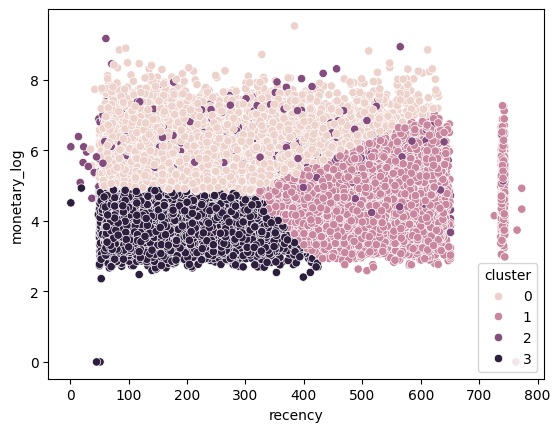

In [42]:
import seaborn as sns

sns.scatterplot(
    data=rfm_log,
    x="recency",
    y="monetary_log",
    hue="cluster"
)

<Axes: xlabel='frequency_log', ylabel='monetary_log'>

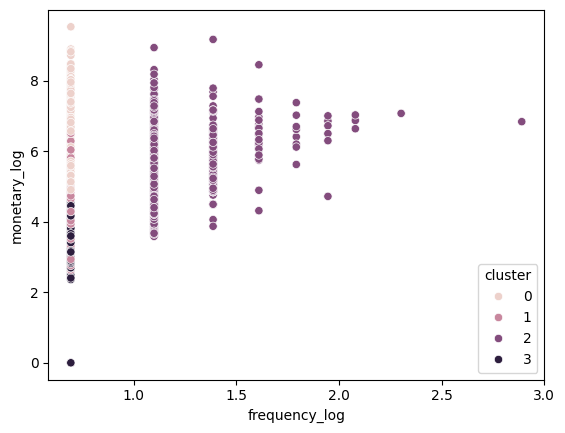

In [41]:
import seaborn as sns

sns.scatterplot(
    data=rfm_log,
    x="frequency_log",
    y="monetary_log",
    hue="cluster"
)

- Customer clusters are visualized using recency and log-transformed monetary values.
- Since clustering was performed using three features (recency, frequency, and monetary), the scatter plot represents only a two-dimensional projection of the clustering space.

### Final Clustering Observations

- Applying log transformation reduced the influence of extreme monetary outliers during clustering.
- Cluster separation became more behaviorally meaningful after balancing the contribution of frequency and monetary features.
- Customer groups were differentiated not only by spending amount, but also by engagement patterns such as repeat purchasing behavior and inactivity.
- Most customers in the dataset were one-time purchasers, which naturally limited the diversity of customer segments.
- Repeat customers formed a distinct cluster with relatively higher purchase frequency and moderate spending behavior.
- Inactive low-value customers were successfully separated based on high recency values and low monetary contribution.

Overall, the transformed clustering approach produced more interpretable and business-relevant customer segments compared to clustering on raw RFM features.